In [1]:
import numpy as np
import shap
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

from xgboost import XGBRegressor 
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.manifold import TSNE
from tqdm import tqdm

/insomnia001/depts/iicd/users/vj2308/miniconda/envs/medal-captum/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### MNIST 
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X_scaled=X/255.0
train=X_scaled[:10000]
labels_train=y[:10000]
test=X_scaled[10000:10500]
labels_test=y[10000:10500]

In [4]:
### train t-SNE
tsne=TSNE(
    n_components=2,
    perplexity=256
)
tnse_fit=tsne.fit_transform(train)

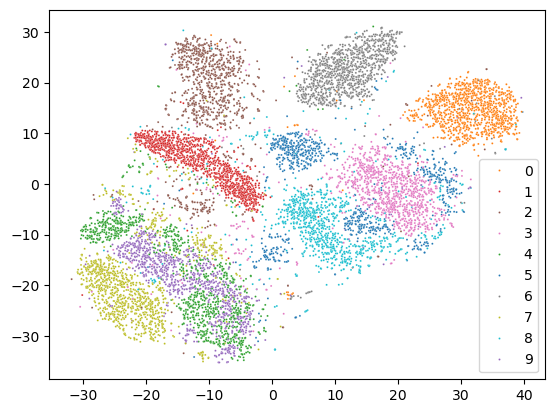

In [5]:
ax=sns.scatterplot(x=tnse_fit[:,0], y=tnse_fit[:,1], hue=labels_train, s=2)
handles, labels = ax.get_legend_handles_labels()
order=[1,3,5,6,2,0,7,8,9,4]
ax.legend([handles[i] for i in order], [labels[i] for i in order])
plt.show()

In [6]:
lat0_coord=tnse_fit[:,0]
lat1_coord=tnse_fit[:,1]

In [7]:
model_0=XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.7, colsample_bytree=0.8)
model_0.fit(train, lat0_coord)

model_1=XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.7, colsample_bytree=0.8)
model_1.fit(train, lat1_coord)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
import shap, xgboost 
print(shap.__version__)
print(xgboost.__version__)  #3.0.3 make sure it is 3.0.3

0.48.0
3.0.3


In [9]:
### tree explainer
xg_values_list_avg=[]
xg_values_list_l2=[]

for i in tqdm(range(10)):
    batch=min(len(train[labels_train==str(i)]), 128)
    explainer0=shap.TreeExplainer(
        model_0,
        train[labels_train==str(i)][:batch]
        )    
    shap_values0=explainer0.shap_values(train[labels_train==str(i)])
    explainer1=shap.TreeExplainer(
        model_1,
        train[labels_train==str(i)][:batch]
        )    
    shap_values1=explainer1.shap_values(train[labels_train==str(i)])

    xg_values_list_avg.append(np.mean((shap_values0+shap_values1)/2, axis=0))
    l2=np.sqrt(np.square(shap_values0) + np.square(shap_values1))
    xg_values_list_l2.append(np.mean(l2, axis=0))

100%|██████████████████████████████████████████| 10/10 [14:09<00:00, 84.96s/it]


In [10]:
# overlaying the features above on original data image
def overlay_features(fa_values_list, title, top_k=10):
     '''
    This function colors the top k pixels with the highest magnitude of 
    feature attribution values on top of the grayscaled image for each digit class. 
    This function shows local attribution.
    
    Input: 
        fa_values: a list of 10 lists of local feature attribution values for each digit class 
        title: str; title for the figure
        top_k: int; how many pixels to color
    Output:
        Displays a 2 by 5 plot of gray scaled digits 0-9 with colored pixels.
    '''
    
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):   #from digits 0-9
        fa_val=fa_values_list[i][0]  #on the first image 
        og_image=train[labels_train==str(i)][0].reshape(28,28)  #on the first image

        top_indices=np.argsort(np.abs(fa_val), axis=None)[-top_k:]
        top_y,top_x=np.unravel_index(top_indices,(28,28))

        colors=np.zeros((28,28,3), dtype=float)
        for y,x in zip(top_y,top_x):
            if fa_val[y*28+x].item()>0:
                colors[y,x]=[1,0,0]  #red if attribution value is positive
            else:
                colors[y,x]=[0,0,1]  #blue if attribution value is negative
        ax[i//5, i%5].imshow(og_image, cmap="gray")
        ax[i//5, i%5].imshow(colors, alpha=0.6)
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

def global_overlay_features(fa_values_avg, title, top_k=10):
    '''
    This function colors the top k pixels with the highest magnitude of 
    feature attribution values on top of the averaged grayscaled image of each digit class. 
    This function shows global attribution.
    
    Input: 
        fa_avg_values: a list of 10 lists of averaged feature attribution values for each digit class 
        title: str; title for the figure
        top_k: int; how many pixels to color
    Output:
        Displays a 5 by 2 plot of gray scaled digits 0-9 with colored pixels.
    '''
    
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        fa_val=fa_values_avg[i]
        og_image=train[labels_train==str(i)].mean(axis=0).reshape(28,28)

        top_indices=np.argsort(np.abs(fa_val), axis=None)[-top_k:]
        top_y,top_x=np.unravel_index(top_indices,(28,28))

        colors=np.zeros((28,28,3), dtype=float)
        for y,x in zip(top_y,top_x):
            if ig_val[y*28+x].item()>0:
                colors[y,x]=[1,0,0]  #red if avg attr value is positive
            else:
                colors[y,x]=[0,0,1]  #blue if avg attr value is negative
        ax[i//5, i%5].imshow(og_image, cmap="gray")
        ax[i//5, i%5].imshow(colors, alpha=0.6)
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

## add heat map option
def heatmap_features(fa_values_avg, title):
    '''
    This function plots a heatmap of the global feature attribution values
    Input: 
        fa_values: a list of 10 lists of averaged feature attribution values for each digit class
        title: str; title for the figure
    Output:
        Displays a 5 by 2 heatmap plot of global feature attribution values.
    '''
    
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        fa_val=fa_values_avg[i]/np.sum(fa_values_avg[i])
        
        ax[i//5, i%5].imshow(fa_val.reshape(28,28),cmap="turbo")
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

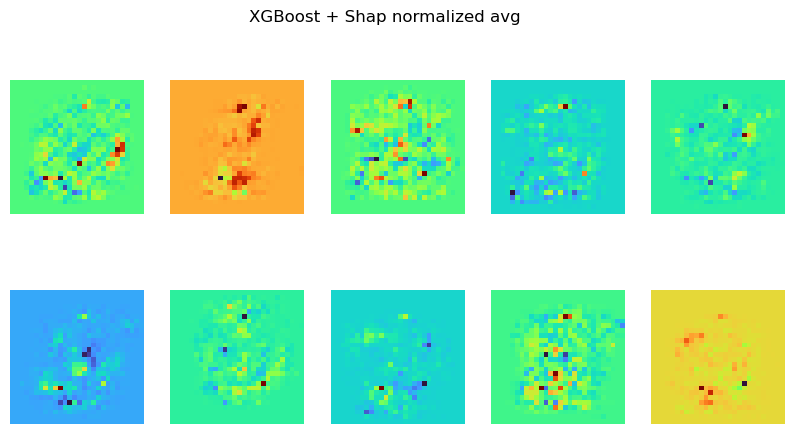

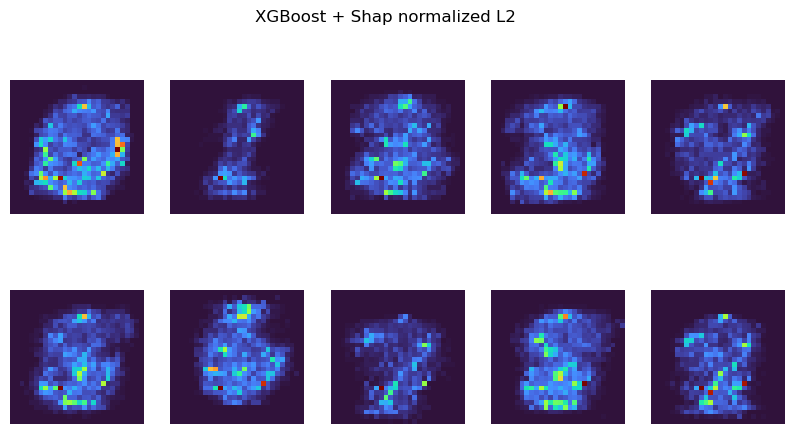

In [11]:
heatmap_features(xg_values_list_avg,"XGBoost + Shap normalized avg")
heatmap_features(xg_values_list_l2,"XGBoost + Shap normalized L2")